In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
 
import tensorflow as tf
from keras._tf_keras.keras.models import Sequential, load_model
from keras._tf_keras.keras.layers import Dense, Dropout, BatchNormalization
from keras._tf_keras.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras._tf_keras.keras.optimizers import Adam
from matplotlib.pyplot import Circle
import keras

### Constants

In [2]:

filename="closer_data_coords.csv"
scaler = MinMaxScaler()
model_name = "Gesture_model"
FRAMES = 5
LAMBDA_V = 0.01
LAMBDA_A = 0.01


## Data Init and Class Distributions

In [3]:
df = pd.read_csv(filename)
df.drop(columns=['source_file', 'source_directory'], inplace=True, errors='ignore')
df.columns = [col.replace('.', '_') for col in df.columns]
df = df.drop(columns=[c for c in df.columns if '_z' in c], errors='ignore')
df.dropna(inplace=True)
 
# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df['gesture_class'])
num_classes = len(label_encoder.classes_)
 
print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}\n")
print(f'Data shape: {df.shape}')



Number of classes: 5
Classes: ['A-sign' 'B-sign' 'Okay' 'peace_sign' 'thumbs_up']

Data shape: (496, 43)


In [4]:
print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}\n")

print(f'data shape: {df.shape}')
print(f'df columns: {df.columns}')


Number of classes: 5
Classes: ['A-sign' 'B-sign' 'Okay' 'peace_sign' 'thumbs_up']

data shape: (496, 43)
df columns: Index(['gesture_class', 'WRIST_x', 'WRIST_y', 'THUMB_CMC_x', 'THUMB_CMC_y',
       'THUMB_MCP_x', 'THUMB_MCP_y', 'THUMB_IP_x', 'THUMB_IP_y', 'THUMB_TIP_x',
       'THUMB_TIP_y', 'INDEX_FINGER_MCP_x', 'INDEX_FINGER_MCP_y',
       'INDEX_FINGER_PIP_x', 'INDEX_FINGER_PIP_y', 'INDEX_FINGER_DIP_x',
       'INDEX_FINGER_DIP_y', 'INDEX_FINGER_TIP_x', 'INDEX_FINGER_TIP_y',
       'MIDDLE_FINGER_MCP_x', 'MIDDLE_FINGER_MCP_y', 'MIDDLE_FINGER_PIP_x',
       'MIDDLE_FINGER_PIP_y', 'MIDDLE_FINGER_DIP_x', 'MIDDLE_FINGER_DIP_y',
       'MIDDLE_FINGER_TIP_x', 'MIDDLE_FINGER_TIP_y', 'RING_FINGER_MCP_x',
       'RING_FINGER_MCP_y', 'RING_FINGER_PIP_x', 'RING_FINGER_PIP_y',
       'RING_FINGER_DIP_x', 'RING_FINGER_DIP_y', 'RING_FINGER_TIP_x',
       'RING_FINGER_TIP_y', 'PINKY_MCP_x', 'PINKY_MCP_y', 'PINKY_PIP_x',
       'PINKY_PIP_y', 'PINKY_DIP_x', 'PINKY_DIP_y', 'PINKY_TIP_x',
       '

### Sliding window function

In [5]:
def sliding_window(X, y, frames=5):
    xs, ys = [], []
    for i in range(len(X) - frames + 1):
        xs.append(X.iloc[i:i+frames].values)
        ys.append(int(y.iloc[i+frames - 1]))
    return np.array(xs), np.array(ys)


## Data Visualization Functions

### Plot hand landmarks

In [6]:
def plot_hand_landmarks(X_raw, y_raw, label_encoder, num_samples=5):
    HAND_CONNECTIONS = [
        (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),  # Index
        (0, 9), (9, 10), (10, 11), (11, 12),  # Middle
        (0, 13), (13, 14), (14, 15), (15, 16),  # Ring
        (0, 17), (17, 18), (18, 19), (19, 20),  # Pinky
        (5, 9), (9, 13), (13, 17)  # Palm
    ]
    
    num_gestures = len(label_encoder.classes_)
    fig, axes = plt.subplots(num_gestures, num_samples, 
                             figsize=(3*num_samples, 3*num_gestures))
    
    if num_gestures == 1:
        axes = axes.reshape(1, -1)
    
    feature_names = X_raw.columns.tolist()
    x_features = [f for f in feature_names if '_x' in f]
    y_features = [f for f in feature_names if '_y' in f]
    num_landmarks = min(len(x_features), len(y_features))
    
    for gesture_idx, gesture_name in enumerate(label_encoder.classes_):
        gesture_mask = y_raw == gesture_idx
        gesture_samples = X_raw[gesture_mask]
        
        sample_indices = np.random.choice(len(gesture_samples), 
                                         min(num_samples, len(gesture_samples)), 
                                         replace=False)
        
        for plot_idx, sample_idx in enumerate(sample_indices):
            ax = axes[gesture_idx, plot_idx] if num_gestures > 1 else axes[plot_idx]
            
            x_coords = gesture_samples.iloc[sample_idx][x_features].values
            y_coords = -gesture_samples.iloc[sample_idx][y_features].values
            
            for connection in HAND_CONNECTIONS:
                if connection[0] < num_landmarks and connection[1] < num_landmarks:
                    ax.plot([x_coords[connection[0]], x_coords[connection[1]]],
                           [y_coords[connection[0]], y_coords[connection[1]]],
                           'b-', linewidth=2, alpha=0.6)
            
            ax.scatter(x_coords[:num_landmarks], y_coords[:num_landmarks], 
                      c='red', s=50, zorder=5, edgecolors='black', linewidth=1)
            
            ax.scatter(x_coords[0], y_coords[0], 
                      c='green', s=100, zorder=6, edgecolors='black', linewidth=2,
                      marker='s', label='Wrist')
            
            ax.set_xlim(x_coords.min() - 0.05, x_coords.max() + 0.05)
            ax.set_ylim(y_coords.min() - 0.05, y_coords.max() + 0.05)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            
            if plot_idx == 0:
                ax.set_ylabel(f'{gesture_name}', fontsize=11, fontweight='bold')
            if gesture_idx == 0:
                ax.set_title(f'Sample {plot_idx + 1}', fontsize=10)
            
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.suptitle('Hand Landmark Visualization by Gesture Class', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('hand_shape_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
 


### Feature space

In [7]:
def plot_feature_space(X_window, y_window, label_encoder, frame_idx=2, 
                       feature1_idx=16, feature2_idx=17):
    """Plot 2D feature space for two selected features"""
    feature_names = list(X_raw.columns)
    feature1_name = feature_names[feature1_idx]
    feature2_name = feature_names[feature2_idx]
    
    feature1_values = X_window[:, frame_idx, feature1_idx]
    feature2_values = X_window[:, frame_idx, feature2_idx]
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(label_encoder.classes_)))
    fig, ax = plt.subplots(figsize=(12, 10))
    
    for gesture_idx, gesture_name in enumerate(label_encoder.classes_):
        mask = y_window == gesture_idx
        ax.scatter(feature1_values[mask], feature2_values[mask],
                  c=[colors[gesture_idx]], 
                  label=gesture_name,
                  alpha=0.6, 
                  s=50,
                  edgecolors='black',
                  linewidth=0.5)
    
    ax.set_xlabel(f'{feature1_name} (Frame {frame_idx})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{feature2_name} (Frame {frame_idx})', fontsize=12, fontweight='bold')
    ax.set_title(f'Feature Space: {feature1_name} vs {feature2_name}', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'2d_feature_space_frame{frame_idx}.png', dpi=300)
    plt.show()
 


### Model visualization

In [8]:
def visualize_neural_network(model, X_sample, layer_names=None):
    # Ensure sample matches model input shape
    input_shape = model.base_model.input_shape  # (batch, ...) or (...,)
    if isinstance(input_shape, tuple):
        expected_features = int(np.prod(input_shape[1:])) if len(input_shape) > 1 else int(np.prod(input_shape))
    else:
        expected_features = None

    # Prepare X_input with proper batch and spatial dims
    X = np.array(X_sample)
    if expected_features is not None and X.size == expected_features:
        # flat vector: reshape to model input (exclude batch dim)
        target_shape = input_shape[1:] if len(input_shape) > 1 else (expected_features,)
        X_input = X.reshape((1,) + target_shape)
    else:
        # try to add batch dim if missing
        if X.ndim == len(input_shape) - 1:
            X_input = X.reshape((1,) + X.shape)
        elif X.ndim == len(input_shape):
            X_input = X
        else:
            # fallback: flatten to 1D and pass as (1, -1)
            X_input = X.reshape(1, -1)

    # Select layers to visualize: prefer Dense layers; for conv layers use channel count
    selected_layers = []
    layer_labels = ['Input\n(Features)']
    for layer in model.base_model.layers:
        # choose Dense and Conv-like layers
        if isinstance(layer, tf.keras.layers.Dense):
            selected_layers.append(layer)
            layer_labels.append(f'{layer.__class__.__name__}\n({layer.units} units)')
        elif isinstance(layer, (tf.keras.layers.Conv1D, tf.keras.layers.Conv2D, tf.keras.layers.Conv3D)):
            channels = int(layer.output_shape[-1])
            selected_layers.append(layer)
            layer_labels.append(f'{layer.__class__.__name__}\n({channels} ch)')

    if not selected_layers:
        raise RuntimeError("No suitable layers found to visualize (no Dense/Conv layers).")

    # Build intermediate model
    intermediate_model = tf.keras.Model(
        inputs=model.base_model.input,
        outputs=[layer.output for layer in selected_layers]
    )

    # Get activations
    activations = intermediate_model.predict(X_input, verbose=0)

    # Convert activations to 2D per-layer vectors (neurons x scalar)
    acts_2d = []
    for act in activations:
        # act shape: (batch, ...) ; reduce spatial dims by mean to get per-channel/neuron scalar
        arr = np.array(act[0])  # remove batch
        if arr.ndim == 0:
            vec = np.array([arr])
        elif arr.ndim == 1:
            vec = arr
        else:
            # collapse spatial dims, keep last dim as "neurons" (channels)
            vec = arr.reshape(-1, arr.shape[-1]).mean(axis=0)
        acts_2d.append(vec)

    # --- PLOTTING (left: architecture, right: heatmap) ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    ax1, ax2 = axes

    # Layer sizes for layout: input size then each selected layer length
    layer_sizes = [X_input.shape[1] if X_input.ndim == 2 else int(np.prod(X_input.shape[1:]))]
    for v in acts_2d:
        layer_sizes.append(len(v))
    num_layers = len(layer_sizes)
    layer_positions = np.linspace(0, 10, num_layers)
    neuron_positions = []

    for i, (layer_size, x_pos) in enumerate(zip(layer_sizes, layer_positions)):
        y_positions = np.linspace(0, 10, max(1, layer_size))
        neuron_positions.append(y_positions)
        for y_pos in y_positions:
            circle = Circle((x_pos, y_pos), 0.15,
                            color='lightblue' if i == 0 else 'lightcoral' if i == num_layers-1 else 'lightgreen',
                            ec='black', linewidth=1.0, zorder=4)
            ax1.add_patch(circle)

    # Connections (sample)
    for i in range(num_layers - 1):
        src = neuron_positions[i]
        tgt = neuron_positions[i+1]
        num_pairs = len(src) * len(tgt)
        max_connections = 50
        if num_pairs > max_connections:
            idxs = np.random.choice(num_pairs, max_connections, replace=False)
        else:
            idxs = range(num_pairs)
        for conn_idx in idxs:
            s = conn_idx // len(tgt)
            t = conn_idx % len(tgt)
            ax1.plot([layer_positions[i], layer_positions[i+1]], [src[s], tgt[t]],
                     'gray', alpha=0.2, linewidth=0.5, zorder=1)

    for i, (x_pos, label) in enumerate(zip(layer_positions, ['Input'] + layer_labels[1:])):
        ax1.text(x_pos, -1, label, ha='center', fontsize=9, fontweight='bold')

    ax1.set_xlim(-1, 11); ax1.set_ylim(-2, 11); ax1.axis('off'); ax1.set_title('Neural Network Architecture')

    # Heatmap: rows = neuron index, cols = layer index
    max_units = max(len(v) for v in acts_2d)
    activation_matrix = np.zeros((max_units, len(acts_2d)))
    for j, vec in enumerate(acts_2d):
        activation_matrix[:len(vec), j] = vec

    im = ax2.imshow(activation_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')
    ax2.set_xlabel('Layer Index'); ax2.set_ylabel('Neuron Index')
    ax2.set_title('Forward Pass Activations (Sample Input)')
    plt.colorbar(im, ax=ax2, label='Activation')
    plt.tight_layout()
    plt.savefig('neural_network_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

In [9]:
def plot_training_comparison(history_base, history_physics):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss comparison
    axes[0, 0].plot(history_base.history['loss'], label='Base Model', linewidth=2)
    axes[0, 0].plot(history_physics.history['loss'], label='Physics Model', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontweight='bold')
    axes[0, 0].set_ylabel('Loss', fontweight='bold')
    axes[0, 0].set_title('Training Loss Comparison', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Validation loss comparison
    axes[0, 1].plot(history_base.history['val_loss'], label='Base Model', linewidth=2)
    axes[0, 1].plot(history_physics.history['val_loss'], label='Physics Model', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontweight='bold')
    axes[0, 1].set_ylabel('Validation Loss', fontweight='bold')
    axes[0, 1].set_title('Validation Loss Comparison', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Accuracy comparison
    axes[1, 0].plot(history_base.history['accuracy'], label='Base Model', linewidth=2)
    axes[1, 0].plot(history_physics.history['accuracy'], label='Physics Model', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontweight='bold')
    axes[1, 0].set_ylabel('Accuracy', fontweight='bold')
    axes[1, 0].set_title('Training Accuracy Comparison', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Validation accuracy comparison
    axes[1, 1].plot(history_base.history['val_accuracy'], label='Base Model', linewidth=2)
    axes[1, 1].plot(history_physics.history['val_accuracy'], label='Physics Model', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontweight='bold')
    axes[1, 1].set_ylabel('Validation Accuracy', fontweight='bold')
    axes[1, 1].set_title('Validation Accuracy Comparison', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
 


In [10]:
def visualize_gradient_descent_simple(X, y, num_iterations=50, learning_rate=0.01):
    from sklearn.decomposition import PCA
    
    # Reduce to 1D
    pca = PCA(n_components=1)
    X_1d = pca.fit_transform(X)
    
    # Add bias
    X_1d_bias = np.c_[np.ones(X_1d.shape[0]), X_1d]
    y_reshaped = y.reshape(-1, 1)
    
    w = np.random.randn(2, 1) * 0.01
    w_history = [w.copy()]
    cost_history = []
    
    def compute_cost(X, y, w):
        m = len(y)
        predictions = X @ w
        cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
        return cost
    
    def compute_gradient(X, y, w):
        m = len(y)
        gradient = (1 / m) * X.T @ (X @ w - y)
        return gradient
    
    cost_history.append(compute_cost(X_1d_bias, y_reshaped, w))
    
    # Gradient descent
    for i in range(num_iterations):
        gradient = compute_gradient(X_1d_bias, y_reshaped, w)
        w = w - learning_rate * gradient
        w_history.append(w.copy())
        cost_history.append(compute_cost(X_1d_bias, y_reshaped, w))
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: Cost vs Iteration
    axes[0].plot(cost_history, 'b-', linewidth=2)
    axes[0].set_xlabel('Iteration', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Cost J(w)', fontsize=12, fontweight='bold')
    axes[0].set_title('Cost vs. Iteration', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Cost surface with path
    w1_range = np.linspace(w_history[0][1, 0] - 2, w_history[0][1, 0] + 2, 100)
    costs_w1 = []
    
    for w1_val in w1_range:
        w_temp = np.array([[w_history[-1][0, 0]], [w1_val]])
        costs_w1.append(compute_cost(X_1d_bias, y_reshaped, w_temp))
    
    axes[1].plot(w1_range, costs_w1, 'b-', linewidth=2, label='J(w)')
    
    w1_path = [w[1, 0] for w in w_history]
    
    # Show first 15 steps
    for i in range(min(15, len(w1_path)-1)):
        axes[1].annotate('', xy=(w1_path[i+1], cost_history[i+1]),
                        xytext=(w1_path[i], cost_history[i]),
                        arrowprops=dict(arrowstyle='->', color='red', lw=2))
    
    axes[1].scatter(w1_path[0], cost_history[0], c='green', s=200, 
                   marker='o', zorder=5, edgecolors='black', linewidth=2, label='Start')
    axes[1].scatter(w1_path[-1], cost_history[-1], c='red', s=200,
                   marker='*', zorder=5, edgecolors='black', linewidth=2, label='End')
    
    axes[1].set_xlabel('Parameter w₁', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Cost J(w)', fontsize=12, fontweight='bold')
    axes[1].set_title('Gradient Descent on Cost Function', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Parameter evolution
    w0_path = [w[0, 0] for w in w_history]
    iterations = range(len(w0_path))
    
    ax3_twin = axes[2].twinx()
    
    line1 = axes[2].plot(iterations, w0_path, 'b-', linewidth=2, label='w₀ (bias)')
    line2 = ax3_twin.plot(iterations, w1_path, 'r-', linewidth=2, label='w₁')
    
    axes[2].set_xlabel('Iteration', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('w₀ Value', fontsize=12, fontweight='bold', color='b')
    ax3_twin.set_ylabel('w₁ Value', fontsize=12, fontweight='bold', color='r')
    axes[2].set_title('Parameter Convergence', fontsize=14, fontweight='bold')
    
    axes[2].tick_params(axis='y', labelcolor='b')
    ax3_twin.tick_params(axis='y', labelcolor='r')
    
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    axes[2].legend(lines, labels, loc='best')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('gradient_descent_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nGradient Descent Summary:")
    print(f"Initial cost: {cost_history[0]:.4f}")
    print(f"Final cost: {cost_history[-1]:.4f}")
    print(f"Cost reduction: {((cost_history[0] - cost_history[-1]) / cost_history[0] * 100):.2f}%")
 

## Feature Transforming

basically, reshaping x and y data into 5 frame windows, then splitting and flattening them for neural network and splitting into training, testing, and cross validation sets. 

In [11]:
X_raw = df.drop(columns=['gesture_class']).apply(pd.to_numeric, errors='coerce')
y_raw = pd.Series(encoded_labels)
 
X_window, y_window = sliding_window(X_raw, y_raw, frames=FRAMES)
print(f'X window shape: {X_window.shape}, y window shape: {y_window.shape}')
 
# Split data
X_train, X_, y_train, y_ = train_test_split(
    X_window, y_window, test_size=0.40, random_state=42
)
 
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_flat = X_.reshape(X_.shape[0], -1)
 
X_cv, X_test, y_cv, y_test = train_test_split(
    X_flat, y_, test_size=0.50, random_state=42
)
 
num_features = X_window.shape[2]
print(f'Training samples: {X_train.shape[0]}, CV: {X_cv.shape[0]}, Test: {X_test.shape[0]}')


X window shape: (492, 5, 42), y window shape: (492,)
Training samples: 295, CV: 98, Test: 99


so the data looks like this, inputs are 5 frames long and are sliding windows. 

In [12]:
print(X_window[1:3][0:5])

[[[0.64358819 0.34949234 0.57814234 0.33898914 0.52694416 0.29842827
   0.50666314 0.26098505 0.49360746 0.22840242 0.54624164 0.24674103
   0.52815413 0.24271192 0.54552531 0.27500027 0.56241721 0.30010429
   0.57954085 0.23847905 0.55877042 0.23957664 0.57870752 0.2776061
   0.59616899 0.30669045 0.6144563  0.23473391 0.59015971 0.23949625
   0.60667551 0.27626082 0.62241888 0.30461383 0.65256733 0.2353542
   0.62438422 0.23698474 0.63104677 0.26582974 0.64188886 0.2877225 ]
  [0.55932403 0.29856652 0.50166166 0.29060873 0.45136246 0.25224602
   0.43217623 0.21479799 0.42500183 0.18392685 0.46809125 0.20762803
   0.45177799 0.1950877  0.46540883 0.22445618 0.48011816 0.24959075
   0.50069231 0.19951315 0.48165366 0.18904406 0.49658448 0.22593835
   0.51096302 0.2560792  0.53567159 0.19466536 0.51178962 0.18918109
   0.52493536 0.2268752  0.53866464 0.25668862 0.57376254 0.19388168
   0.54503882 0.18750283 0.5496915  0.21718228 0.56061864 0.24063455]
  [0.54262376 0.29849446 0.4847644

- There are 42 input features (columns from the df which are the coordinate points from the hand), 
- They are seperated into 5 second intervals, so there are 5 rows of 42 in a single array. 
- And there are 492 samples (timesteps)

## Input feature Visualization

### plotting hand landmarks

In [13]:
target_names=label_encoder.classes_
print(target_names)

['A-sign' 'B-sign' 'Okay' 'peace_sign' 'thumbs_up']


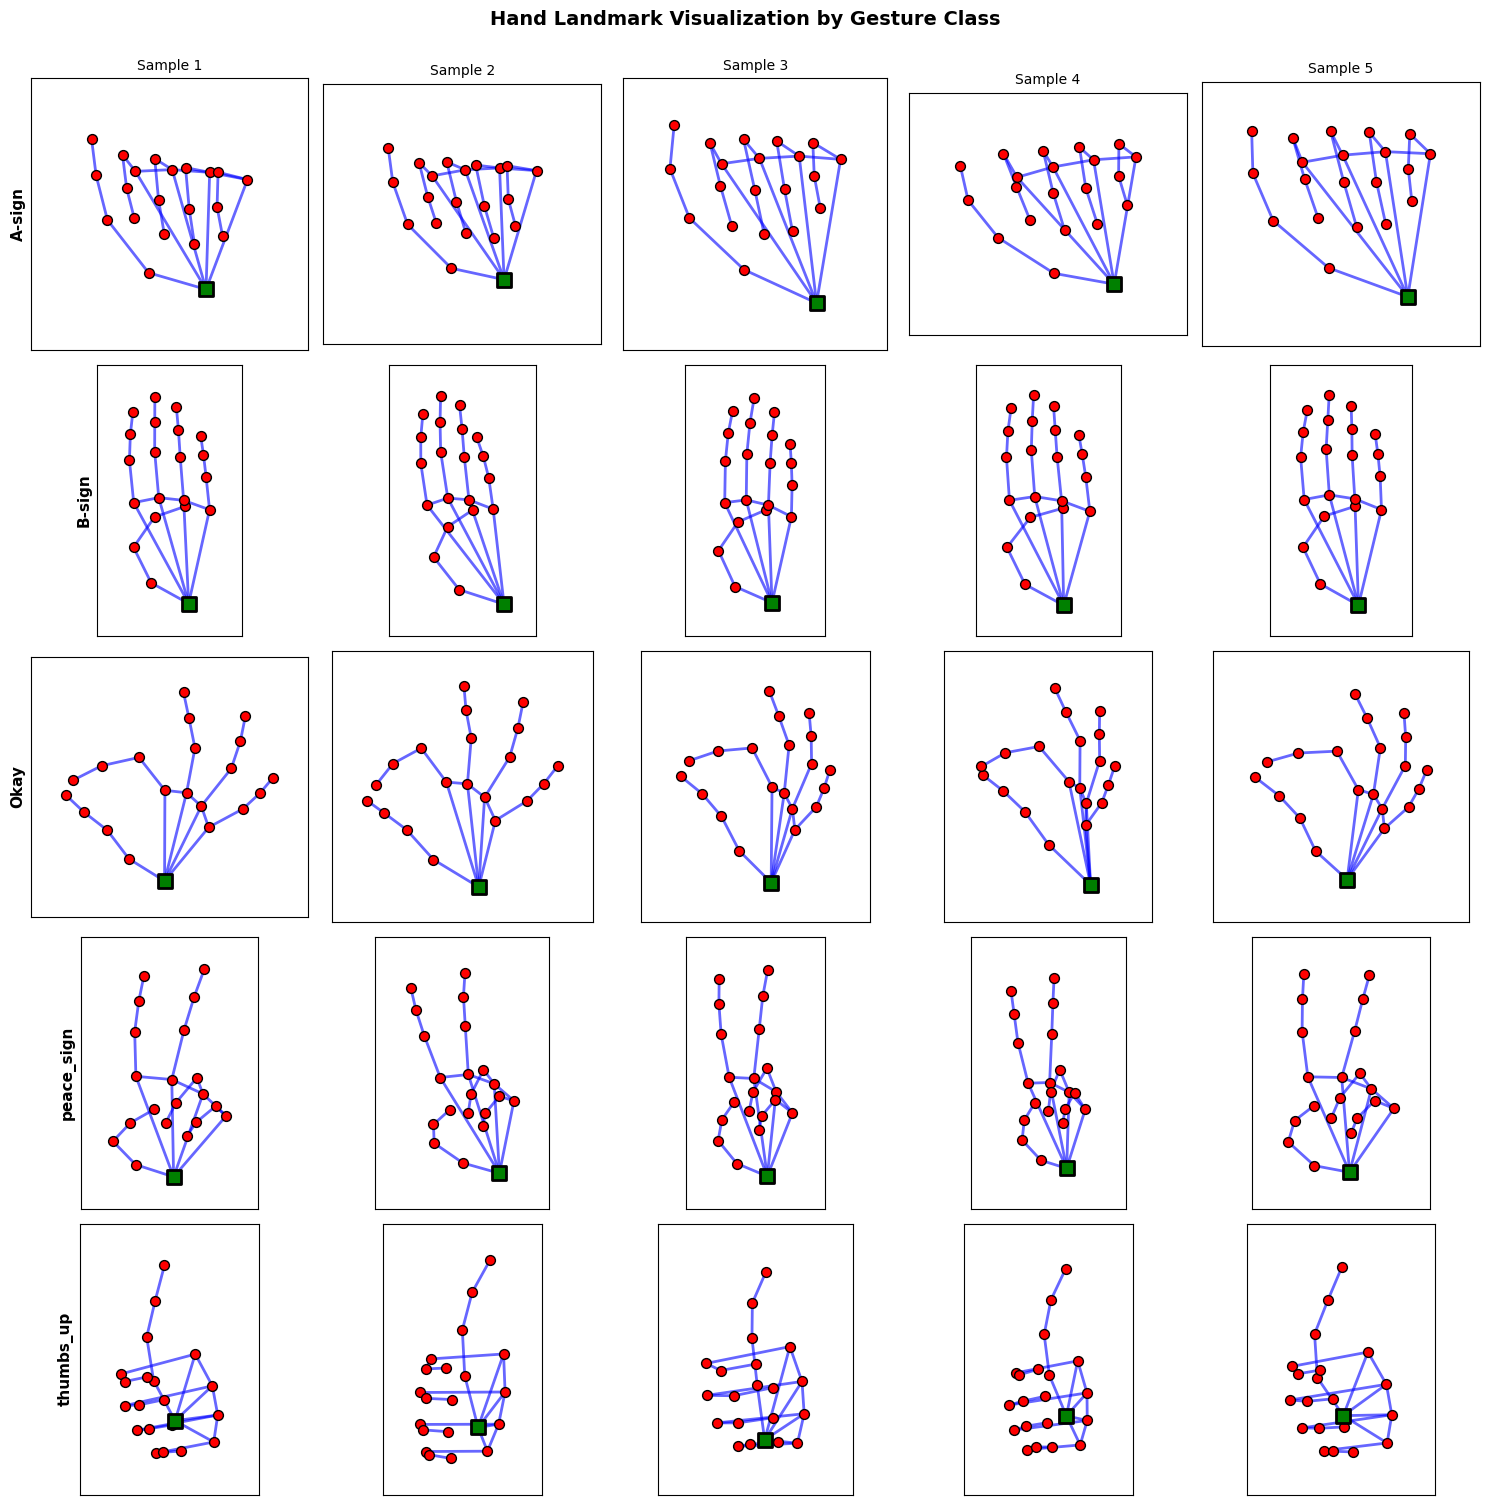

In [14]:
plot_hand_landmarks(X_raw, y_raw, label_encoder, num_samples=5)


### Plotting one feature

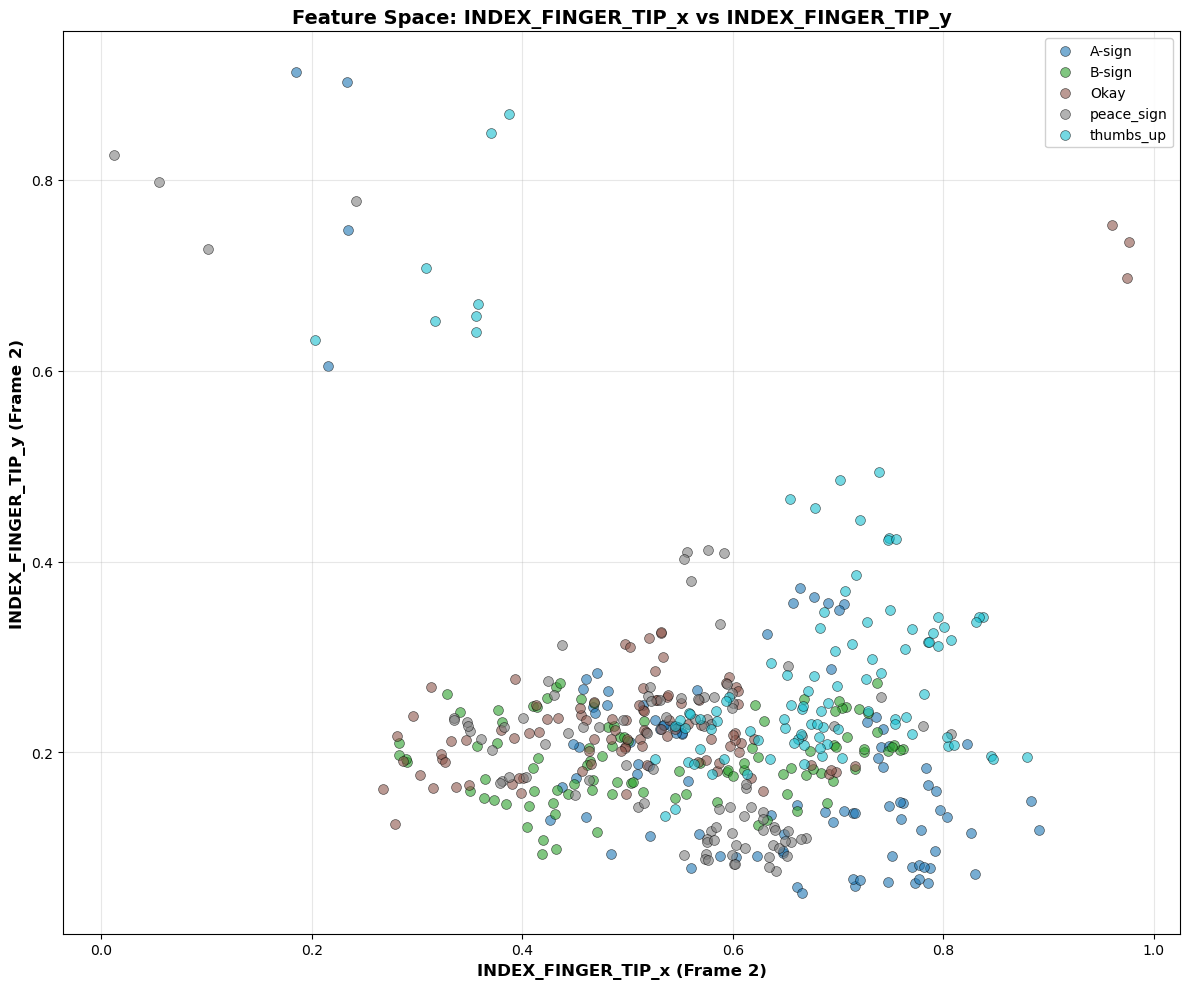

In [15]:
plot_feature_space(X_window, y_window, label_encoder)


## Base Neural Network Creation

In [16]:
def create_base_model(input_dim, num_classes):
    model = Sequential([
        Dense(64, input_dim=input_dim, activation='relu', name='dense_1'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', name='dense_2'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(16, activation='relu', name='dense_3'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax', name='output')
    ], name='base_gesture_model')
    
    return model
 
base_model = create_base_model(FRAMES * num_features, num_classes)
base_model.summary()


c:\Users\isav3\miniconda3\envs\ml\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "base_gesture_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │        13,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,581 (64.77 KB)

 Trainable params: 16,389 (64.02 KB)

 Non-trainable params: 192 (768.00 B)

In [17]:
w1, b1 = base_model.get_layer('dense_1').get_weights()

print(f'Initial (randomized) 2 Weights: {w1[:2]}, \nInitial (randomized) 2 Biases: {b1[:2]}')


Initial (randomized) 2 Weights: [[-0.05901129  0.05344547 -0.09239855 -0.03289389  0.11225381  0.10421845
   0.10178335 -0.01198925 -0.00838283 -0.14609632  0.05705832  0.07772474
   0.07021257  0.06721739 -0.01862207 -0.1408049  -0.1392754  -0.11946028
   0.06036386  0.09218819 -0.02667607  0.03401233 -0.08821793 -0.05596224
   0.1226469   0.07913128 -0.08096416 -0.07794105 -0.00191686  0.1261811
   0.09608756  0.00548351 -0.13575508 -0.06004739 -0.13265692 -0.09192268
  -0.11999799  0.04811096  0.00953616 -0.10021233 -0.07831827 -0.09211542
  -0.12513585 -0.03547779  0.06193453 -0.07969429  0.03494379 -0.09952791
   0.0158968  -0.07271011 -0.02326807 -0.10041502  0.06074937  0.12111565
  -0.12378075  0.10921428 -0.09831016 -0.05485427 -0.13477275 -0.10985667
  -0.09236521 -0.11108193 -0.09243834  0.08390826]
 [-0.00140807 -0.06109992  0.11699146 -0.08583558  0.14374107 -0.01436651
  -0.0866293   0.00457206 -0.02058351  0.00716606 -0.12085871  0.08027788
  -0.07420076  0.00164321  0.0

## Physics Loss Function Creation

### Velocity

The main idea of a physics loss function to to penalize any jerky or unrealistic movements from the model

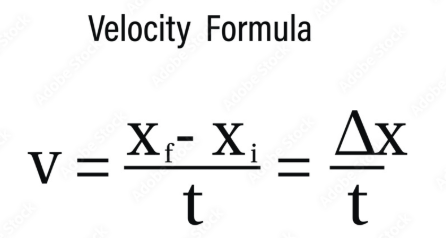

Since our data is already timestepped, take: 

**X1 - X0 = velocity**

If there is a large velocity, thats a jerky motion. **penalize it.**

### Acceleration

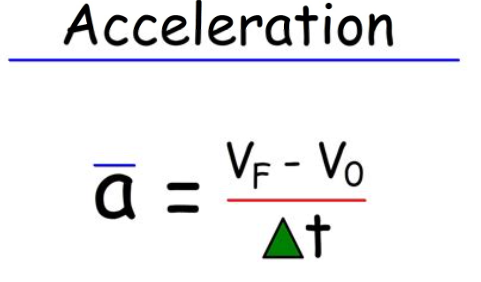

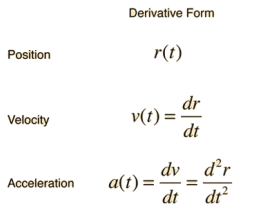

Since Acceleration is the difference in velocity, we can write it as: 

```
(x2 - x1) = v1,
(x1 - x0) = v0, 

v1 - v0 = (x2 - x1) - (x1 - x0) 
=>
```

**acceleration =  x2 - 2x1 + x0** 

If this acceleration is too large, then **penalize it**

### Loss Function formulation

First find the standard loss function from cross entropy

and add the velocity and acceleration values. 

In [32]:
class PhysicsModel(tf.keras.Model):
    def __init__(self, base_model, time_steps, num_features, lambda_v=0.01, lambda_a=0.01):
        super().__init__()
        self.base_model = base_model
        self.time_steps = time_steps
        self.num_features = num_features
        self.lambda_v = lambda_v
        self.lambda_a = lambda_a
        
        # Create metrics to track
        self.train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')
        self.val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')  # Changed from 'val_accuracy'
        
    def call(self, inputs):
        return self.base_model(inputs)
    
    def compute_physics_losses(self, x):
        """Helper method to compute physics losses"""
        batch_size = tf.shape(x)[0]
        x_reshaped = tf.reshape(x, (batch_size, self.time_steps, self.num_features))
        
        # Velocity loss
        velocity = x_reshaped[:, 1:, :] - x_reshaped[:, :-1, :]
        velocity_loss = tf.reduce_mean(tf.square(velocity))
        
        # Acceleration loss
        acceleration = (x_reshaped[:, 2:, :] - 2 * x_reshaped[:, 1:-1, :] + x_reshaped[:, :-2, :])
        acceleration_loss = tf.reduce_mean(tf.square(acceleration))
        
        return velocity_loss, acceleration_loss
    
    def train_step(self, data):
        x, y = data
        
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            
            # Classification loss
            ce_loss = self.compiled_loss(y, y_pred)
            
            # Physics losses
            velocity_loss, acceleration_loss = self.compute_physics_losses(x)
            
            # Total loss
            total_loss = ce_loss + self.lambda_v * velocity_loss + self.lambda_a * acceleration_loss
        
        # Apply gradients
        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        # Update metrics
        self.train_acc_metric.update_state(y, y_pred)

        return {
            "loss": total_loss,
            "ce_loss": ce_loss,
            "velocity_loss": velocity_loss,
            "acceleration_loss": acceleration_loss,
            "accuracy": self.train_acc_metric.result(),
        }
    
    def test_step(self, data):
        x, y = data

        # Forward pass
        y_pred = self(x, training=False)

        # Classification loss
        ce_loss = self.compiled_loss(y, y_pred)
        
        # Physics losses (for monitoring)
        velocity_loss, acceleration_loss = self.compute_physics_losses(x)
        
        # Total loss (same as training)
        total_loss = ce_loss + self.lambda_v * velocity_loss + self.lambda_a * acceleration_loss

        # Update validation metrics
        self.val_acc_metric.update_state(y, y_pred)

        # CRITICAL: Return "accuracy" not "val_accuracy" - Keras adds "val_" prefix automatically
        return {
            "loss": total_loss,
            "ce_loss": ce_loss,
            "velocity_loss": velocity_loss,
            "acceleration_loss": acceleration_loss,
            "accuracy": self.val_acc_metric.result(),  # Changed from "val_accuracy"
        }
    
    @property
    def metrics(self):
        """Reset metrics between epochs"""
        return [self.train_acc_metric, self.val_acc_metric]

### Training basic neural network

In [19]:
base_model = create_base_model(FRAMES * num_features, num_classes)
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
 
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, mode='max', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
 
history_base = base_model.fit(
    X_train_flat, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1593 - loss: 2.2158 - val_accuracy: 0.2222 - val_loss: 1.6504 - learning_rate: 0.0010
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2136 - loss: 1.8536 - val_accuracy: 0.2121 - val_loss: 1.5903 - learning_rate: 0.0010
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2712 - loss: 1.6884 - val_accuracy: 0.2222 - val_loss: 1.5683 - learning_rate: 0.0010
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2847 - loss: 1.6940 - val_accuracy: 0.2222 - val_loss: 1.5558 - learning_rate: 0.0010
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3695 - loss: 1.4432 - val_accuracy: 0.2929 - val_loss: 1.5440 - learning_rate: 0.0010
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4000 - loss: 1.4047 - val_accuracy: 0.2727 - val_loss: 1.5462 - learning_rate: 0.0010
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4339 - loss: 1.3925 - val_ac

### Train physics informed model

In [34]:
physics_base = create_base_model(FRAMES * num_features, num_classes)
physics_model = PhysicsModel(
    base_model=physics_base,
    time_steps=FRAMES,
    num_features=num_features,
    lambda_v=LAMBDA_V,
    lambda_a=LAMBDA_A
)
 
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=0
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-8,
        verbose=0
    )


physics_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history_physics = physics_model.fit(
    X_train_flat, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=0

)


c:\Users\isav3\miniconda3\envs\ml\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\isav3\miniconda3\envs\ml\lib\site-packages\keras\src\backend\tensorflow\trainer.py:673: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(


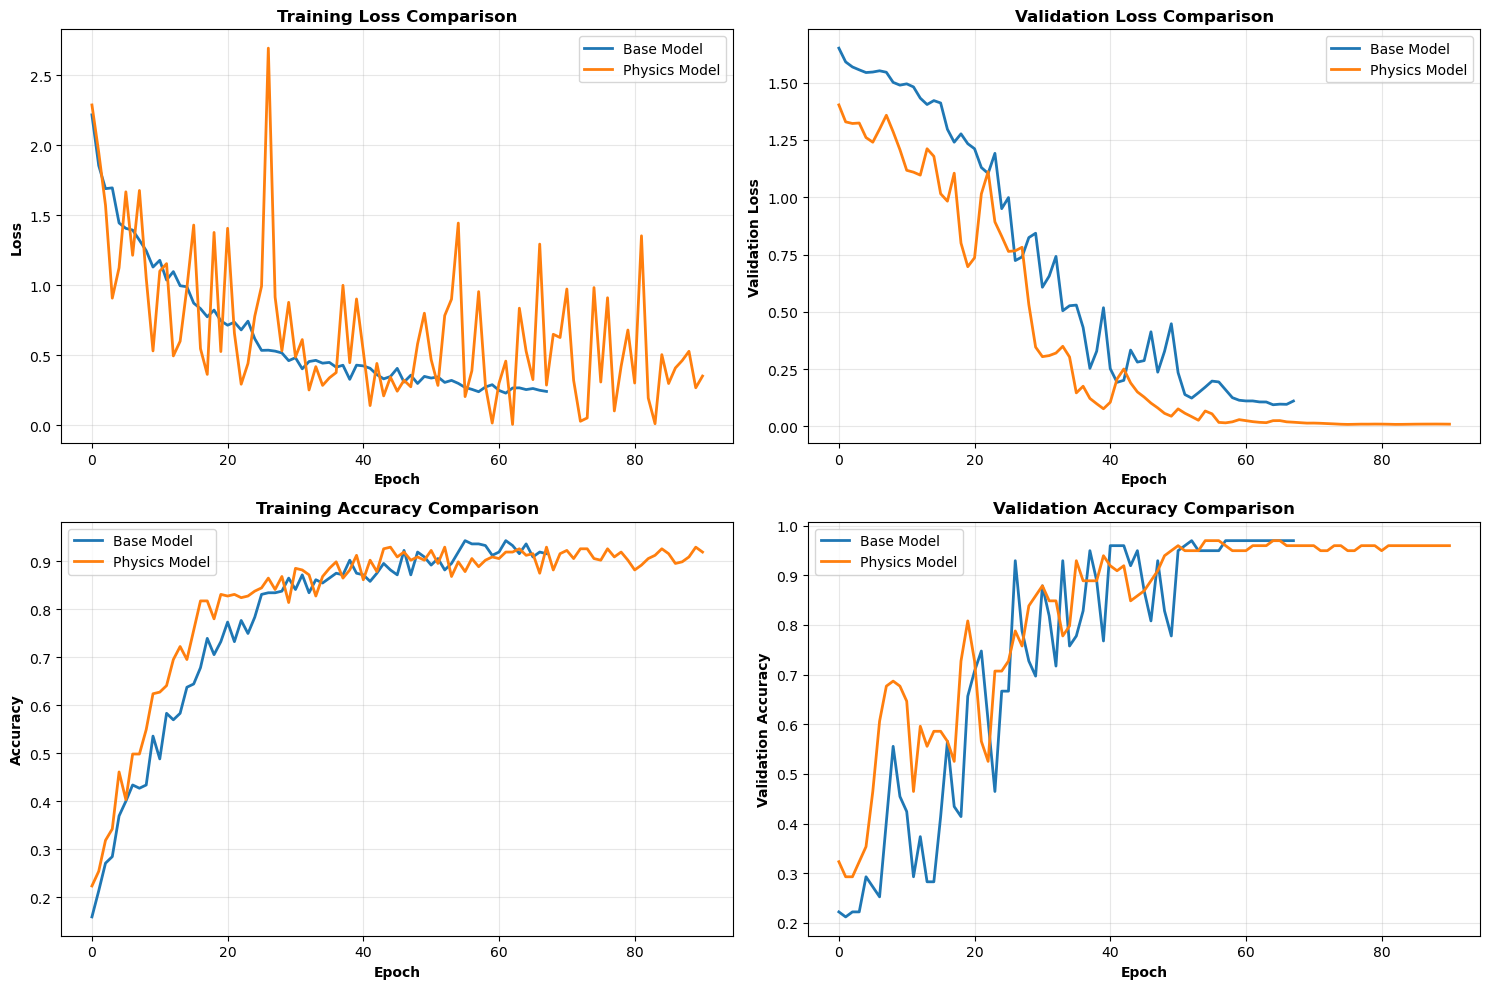

In [35]:
plot_training_comparison(history_base, history_physics)


In [ ]:
import pydot

from keras.utils import plot_model

plot_model(
    base_model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=100
)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


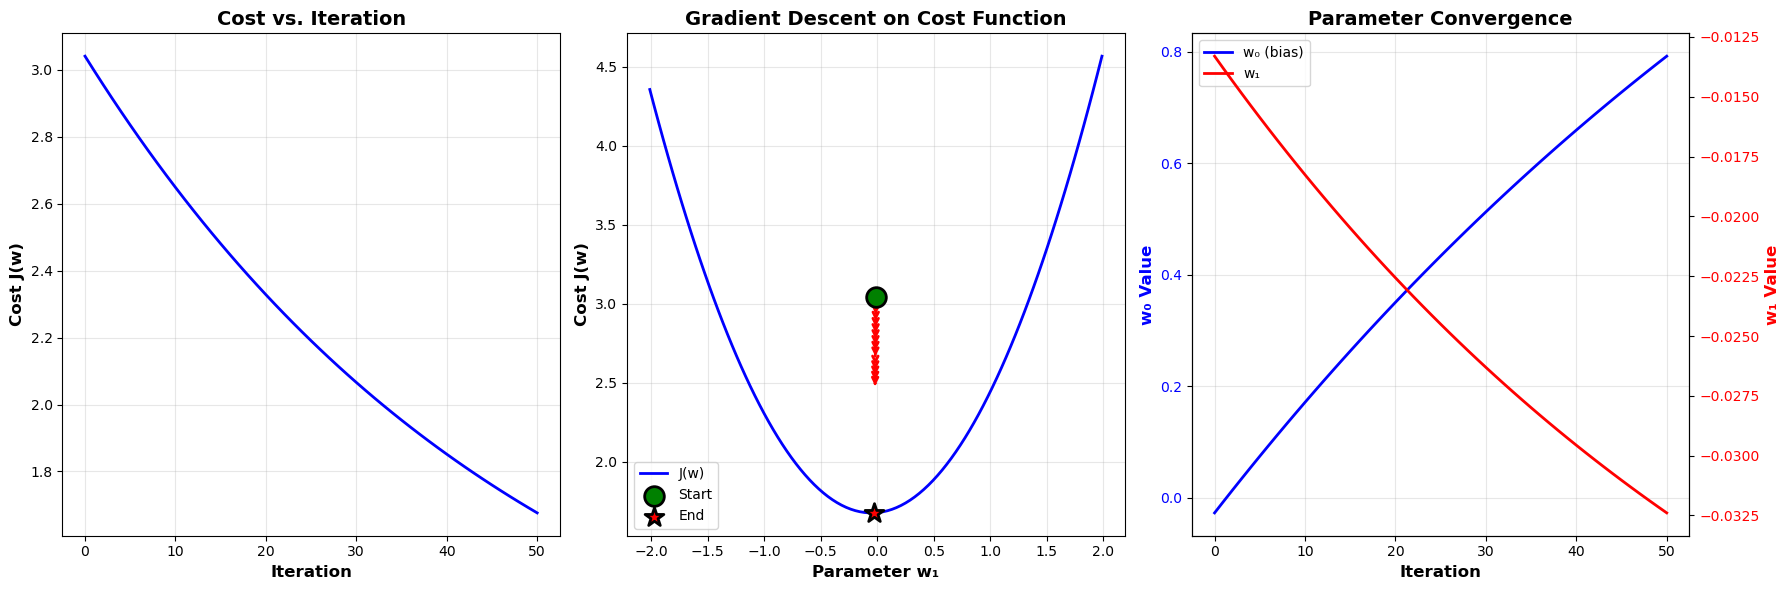


Gradient Descent Summary:
Initial cost: 3.0409
Final cost: 1.6763
Cost reduction: 44.88%


In [ ]:
visualize_gradient_descent_simple(X_train_flat, y_train)


## Model Evaluation 

### Base model

In [22]:
y_pred_base = np.argmax(base_model.predict(X_cv, verbose=0), axis=1)
print("Base Model Cross Validation Classification Report:")
print(classification_report(y_cv, y_pred_base, target_names=label_encoder.classes_))


Base Model Cross Validation Classification Report:
              precision    recall  f1-score   support

      A-sign       1.00      1.00      1.00        18
      B-sign       0.95      1.00      0.98        20
        Okay       1.00      0.87      0.93        15
  peace_sign       1.00      0.95      0.97        20
   thumbs_up       0.93      1.00      0.96        25

    accuracy                           0.97        98
   macro avg       0.98      0.96      0.97        98
weighted avg       0.97      0.97      0.97        98



### Physics informed model

In [23]:
y_pred_physics = np.argmax(physics_model.predict(X_cv, verbose=0), axis=1)
print("Physics Model Cross Validation Classification Report:")
print(classification_report(y_cv, y_pred_physics, target_names=label_encoder.classes_))



Physics Model Cross Validation Classification Report:
              precision    recall  f1-score   support

      A-sign       0.94      0.89      0.91        18
      B-sign       1.00      0.95      0.97        20
        Okay       0.93      0.93      0.93        15
  peace_sign       0.95      0.90      0.92        20
   thumbs_up       0.89      1.00      0.94        25

    accuracy                           0.94        98
   macro avg       0.94      0.93      0.94        98
weighted avg       0.94      0.94      0.94        98



## Model Visualization

### Confusion Matrices:
normalized and non-normalized cms

In [24]:
def plot_confusion_matrices(y_true, y_pred_base, y_pred_physics, label_encoder):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    cm_base = confusion_matrix(y_true, y_pred_base)
    cm_physics = confusion_matrix(y_true, y_pred_physics)
    
    # base model
    sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[0])
    axes[0].set_xlabel("Predicted", fontweight='bold')
    axes[0].set_ylabel("Actual", fontweight='bold')
    axes[0].set_title("Base Model - Confusion Matrix", fontweight='bold', fontsize=14)
    
    # physics model
    sns.heatmap(cm_physics, annot=True, fmt='d', cmap='Reds',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[1])
    axes[1].set_xlabel("Predicted", fontweight='bold')
    axes[1].set_ylabel("Actual", fontweight='bold')
    axes[1].set_title("Physics-Informed Model - Confusion Matrix", fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
 

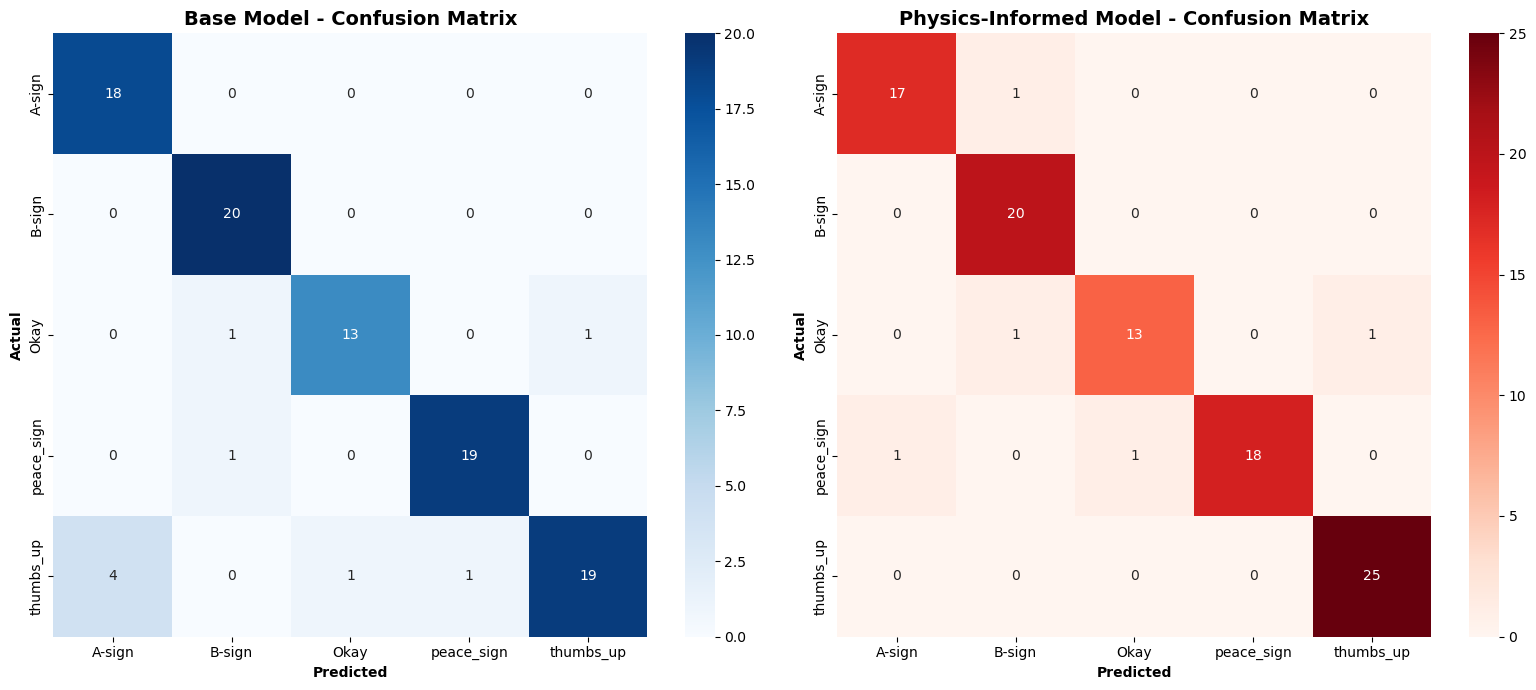

In [ ]:
plot_confusion_matrices(y_cv, y_pred_base, y_pred_physics, label_encoder)

In [25]:
save_dir = 'Trained-Models'
os.makedirs(save_dir, exist_ok=True)
 
base_model.save(os.path.join(save_dir, 'base_model.keras'))
physics_model.base_model.save(os.path.join(save_dir, 'physics_model.keras'))
print(f"\nModels saved to {save_dir}/")



Models saved to Trained-Models/


### Lambda testing

In [26]:
from sklearn.model_selection import ParameterGrid


In [33]:
# Test different combinations of physics weights
lambda_configs = [
    (0.01, 0.01),  # Very light physics
    (0.1, 0.1),    # Light physics
    (0.5, 0.5),    # Medium physics
    (1.0, 1.0),    # Heavy physics
    (0.3, 0.7),    # Favor acceleration
    (0.7, 0.3),    # Favor velocity
]

results = []
best_accuracy = 0
best_config = None

for λ_vel, λ_acc in lambda_configs:
    print(f"\n{'='*60}")
    print(f"Testing λ_velocity={λ_vel}, λ_acceleration={λ_acc}")
    print(f"{'='*60}")
    
    # Re-create the model for each configuration
    physics_base = create_base_model(FRAMES * num_features, num_classes)
    physics_model = PhysicsModel(
        base_model=physics_base,
        time_steps=FRAMES,
        num_features=num_features,
        lambda_v=λ_vel,
        lambda_a=λ_acc
    )
    
    physics_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )
    
    # Create fresh callbacks for each run
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=0
    )
    
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-8,
        verbose=0
    )
    
    # Train the model
    history = physics_model.fit(
        X_train_flat, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # Debug: Print available metrics
    print("Available metrics:", list(history.history.keys()))
    
    # Extract best validation metrics
    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    final_val_acc = history.history['val_accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    # Track training stability (standard deviation of last 10 epochs)
    stability = np.std(history.history['val_accuracy'][-10:])
    
    result = {
        'λ_velocity': λ_vel,
        'λ_acceleration': λ_acc,
        'best_val_accuracy': val_acc,
        'best_val_loss': val_loss,
        'final_val_accuracy': final_val_acc,
        'final_val_loss': final_val_loss,
        'stability': stability,
        'epochs_trained': len(history.history['loss']),
        'history': history.history
    }
    
    results.append(result)
    
    print(f"Best Val Accuracy: {val_acc:.4f}")
    print(f"Final Val Accuracy: {final_val_acc:.4f}")
    print(f"Stability (std): {stability:.4f}")
    
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_config = (λ_vel, λ_acc)

print(f"\n{'='*60}")
print(f"BEST CONFIGURATION: λ_velocity={best_config[0]}, λ_acceleration={best_config[1]}")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")
print(f"{'='*60}")

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'history'} for r in results])
print("\n", results_df.to_string())


Testing λ_velocity=0.01, λ_acceleration=0.01
Available metrics: ['acceleration_loss', 'accuracy', 'ce_loss', 'loss', 'val_acceleration_loss', 'val_accuracy', 'val_ce_loss', 'val_loss', 'val_velocity_loss', 'velocity_loss', 'learning_rate']
Best Val Accuracy: 0.9899
Final Val Accuracy: 0.9596
Stability (std): 0.0000

Testing λ_velocity=0.1, λ_acceleration=0.1
Available metrics: ['acceleration_loss', 'accuracy', 'ce_loss', 'loss', 'val_acceleration_loss', 'val_accuracy', 'val_ce_loss', 'val_loss', 'val_velocity_loss', 'velocity_loss', 'learning_rate']
Best Val Accuracy: 0.9495
Final Val Accuracy: 0.9495
Stability (std): 0.0000

Testing λ_velocity=0.5, λ_acceleration=0.5
Available metrics: ['acceleration_loss', 'accuracy', 'ce_loss', 'loss', 'val_acceleration_loss', 'val_accuracy', 'val_ce_loss', 'val_loss', 'val_velocity_loss', 'velocity_loss', 'learning_rate']
Best Val Accuracy: 0.9697
Final Val Accuracy: 0.9596
Stability (std): 0.0000

Testing λ_velocity=1.0, λ_acceleration=1.0
Availa